# **Decision Trees. First Step Towards Ensemble Learning**

# **Motivation**

Today, the forefront of machine learning and data science is dominated by large language models (LLMs), multi-agent systems, and deep neural networks. Despite their power and widespread use, traditional, simple, and well-interpretable predictive models remain extremely important for business. Decision trees, which form the foundation of one of the most effective algorithms for tabular data, XGBoost, are a prime example of how classical machine learning models lay the groundwork for the further development of artificial intelligence.

Understanding this fundamental algorithm allows us to apply a whole range of ensemble models more effectively and accurately to solve many critical business problems, such as demand forecasting or medical classification.

# **1. Brief Historical Overview**

**Decision trees** have their roots in early statistical classification and decision-making research. Their development spans several fields:statistics, psychology, operations research, and later, artificial intelligence and machine learning.

Early forms of **decision trees** were developed in statistics for classification and prediction. A key milestone was the introduction of AID (Automatic Interaction Detection) by Morgan & Sonquist (1963), one of the first algorithms to generate classification trees.

In time period between 1975–1993 appeared more sophisticated tree-building methods:

1. **CART** (Classification and Regression Trees) by Breiman et al. (1984) established the modern framework for both classification and regression trees;

2. **ID3** algorithm by Quinlan (1986) introduced entropy and information-gain-based splitting and helped popularize decision trees in artificial intelligence;

3. **C4.5**, introduced in 1993, was the  improvement of **ID3** algorithm; it incorporated native processing of continuous features, prunning techniques and became more robust approach than its predecessor.

During the 90s, **decision trees** became a standard method in machine learning due to their interpretability and strong predictive performance. In 2000s they evolved into the **basis of powerful ensemble methods such as**:

1. **Random Forests** (Breiman, 2001);

2. **Gradient Boosting Machines** (GBM);

3. **XGBoost, LightGBM**.

These methods combine multiple trees to achieve higher accuracy and robustness, making them central to modern machine learning and data science.

# **2. Definition**

**Decision trees** can learn patterns from data by recursively splitting features. They not only provides interpretable decision rules, but also serve as the foundation for many high-performing ensemble approaches. Nowaday, they remain widely used for classification, regression, feature importance analysis, and decision support systems.

By definition, **decision tree** is a **predictive model** that organizes decisions and their possible outcomes in the form of a branching, tree-like structure. Each internal node represents a question or condition based on a feature, each branch shows the result of that condition, and each leaf node represents a final prediction or decision. It works step-by-step, splitting data into smaller, more uniform groups, making it intuitive to interpret and visualize. In essence, a decision tree mimics human decision-making: start with a question, follow the answer branch, and continue until you reach a conclusion.

Every day, we make choices often without even realizing it. For example, we decide what to wear based on the weather, or choose what to eat by thinking about what we like and what is available. We naturally follow a step-by-step process: we ask ourselves questions, consider the answers, and then take action.

A **Decision Tree** works in a similar way. Just like we ask questions to guide our choices, a decision tree asks questions to reach a final decision. It helps machines think through possibilities one step at a time, branching out based on answers until it finds the best conclusion.

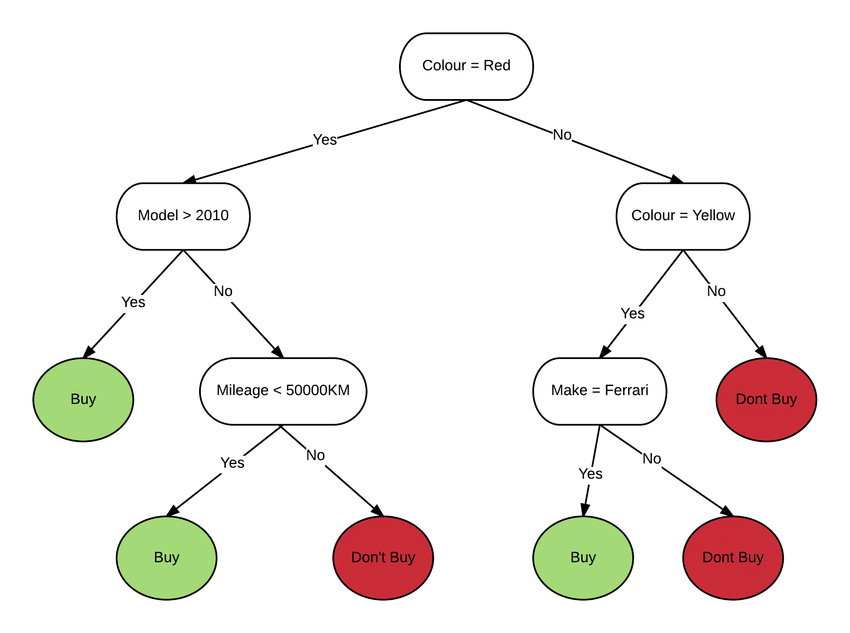

                               Fig. 1. Decision tree example

Source: *Iglesias, Martin. (2021). Dimensional and Discrete Emotion Recognition using Multi-task Learning from Acoustic and Linguistic features extracted from Speech.*

In the visual example below, the decision tree begins with the **root** node labeled **Colour** which represents the top-level decision point. From this node, the decision splits into two possible paths based on the attribute value.

It is common practice for the **Yes** branch to extend to the **left** and the **No** branch to extend to the **right**. As we follow these branches, we encounter additional **internal nodes** that continue to divide the decision process using other features.

Eventually, the traversal reaches the **terminal (leaf) nodes**, which contain the final outcomes. These leaf nodes represent the end of the decision path and provide the resulting classification or decision.

A decision tree typically consists of nodes and edges, structured as follows:

1.   **Root node** is the topmost node, representing the initial decision point.
2.   **Internal (split) nodes** that have children and represent tests or features used to divide the data into subgroups.

3.   **Leaf** or **terminal nodes** without children, representing the final outcome or decision.

4. **Edges** (or **branches**) which are connections between nodes that represent the flow or decision path from one node to another.

# **3. Building the Decision Tree (CART)**

In provided explanatory materials we will  consider **CART** paradigm as the classical and most simple approach. Variations of trees like **ID3** and **C4.5** utilize slightly different techniques for building the decision processes, thus we will not describe them here.

**CART** stands for Classification and Regression Trees. This approach produces only the binary trees, i.e., it always splits nodes into two children (left/right). Also, CART uses different impurity criteria depending on the task: **Gini impurity** for classification and **mean-squared error** (MSE) or **mean absolute error** for regression (we will cover this in the sections below). It can handle both numerical and categorical features and performs **post-pruning** to avoid over-fitting (finds a sequence of pruned subtrees and chooses the best with cross-validation dataset).


To understand how a CART based decision tree is constructed, let’s walk through a simple example.

Assume we have a small weather dataset containing several input parameters, also referred to as features in machine learning. The weather conditions are represented using categorical variables: **Weather** {*Sunny*, *Cloudy*, *Rainy*}, **Wind** {*Weak*, *Strong*}, and a continuous feature **Temp** with values in the range [*18*, *30*].

Our target variable, **Go Outside**, is a binary label with two possible outcomes: {*Yes*, *No*}. What we want is to build the **classification tree** model which will predict the target variable based on the combination of features. If the target is continuous variable, then we get a **regression tree**, another special type of decision tree.  

The dataset below (Table 1) will be used to illustrate how the model learns decision rules from these features.

| Sample | **Weather** | **Wind** | **Temp** (°C) | **Go Outside** |
| :----: | :---------: | :------: | :-----------: | :------------: |
|    1   |    Sunny    |   Weak   |       30      |       Yes      |
|    2   |    Sunny    |  Strong  |       28      |       No       |
|    3   |    Cloudy   |   Weak   |       24      |       Yes      |
|    4   |    Cloudy   |  Strong  |       22      |       Yes      |
|    5   |    Rainy    |   Weak   |       19      |       Yes      |
|    6   |    Rainy    |  Strong  |       20      |       No       |
|    7   |    Sunny    |   Weak   |       25      |       Yes      |


## **3.1. Processing Features/Nodes**

Note, that here we have both categorical and continuous variables. Can we mix them together in **Decision Tree**? Absolutely! Below we will see how to make it properly.

To build a decision tree from the dataset above, the first task is to determine which feature should serve as the **root node**. The **root** should be the feature that most effectively splits the data according to the target label **Go Outside**. In other words, we want the feature that best separates **Yes** and **No** outcomes.

We have three candidate features:

1. **Weather**
2. **Wind**
3. **Temp**

A simple way to begin with is to take one feature, for example, **Weather**, and evaluate how well it predicts the label **Go Outside**. This is our first splitting trial.

For each **Weather** values we can calculate a simple table of how much **Yes** and **No** labels are there for each feature value.

| Weather | Yes |  No | Total |
| :-----: | :-: | :-: | :---: |
|  Sunny  |  2  |  1  |   3   |
|  Cloudy |  2  |  0  |   2   |
|  Rainy  |  1  |  1  |   2   |


The same we can do with **Wind** feature.




|  Wind  | Yes |  No | Total |
| :----: | :-: | :-: | :---: |
|  Weak  |  4  |  0  |   4   |
| Strong |  1  |  2  |   3   |


Decision trees naturally handle categorical features, where a feature can be split based on equality (e.g., **Weather** = Sunny). But what about continuous (numeric) features like **Temp**?

We need a way to split numeric features into two groups: "less than a threshold" and "greater than or equal to a threshold."

**Thresholding** is a trick to convert a continuous feature into binary splits. Here’s how it works:

We sort the **Temp** values in ascending order: [19, 20, 22, 24, 25, 28, 30] and then compute midpoints between consecutive values to generate candidate thresholds: [19.5, 21, 23, 24.5, 26.5, 29].

Then, for each threshold we count the number of **Yes** and **No** labels as "<19.5", "<21", "<23", etc.

For instance,

**Temp** < 21 → [19, 20] → Labels = [Yes, No]

**Temp** ≥ 21 → [22, 24, 25, 28, 30] → Labels = [Yes, Yes, Yes, No, Yes]

This is the typical technique in **CART** classifier, which allows to process continuous features.

| Split Temp < t | Left (Yes/No) | Right (Yes/No) |
| :------------- | :-----------: | :------------: |
| 19.5           |     1 / 0     |      4 / 2     |
| 21.0           |     1 / 1     |      4 / 1     |
| 23.0           |     2 / 1     |      3 / 1     |
| 24.5           |     3 / 1     |      2 / 1     |
| 26.5           |     4 / 1     |      1 / 1     |
| 29.0           |     4 / 2     |      1 / 0     |

## **3.2. Splitting the Tree**

By looking at obtained tables we can see rows like



| Weather | Yes |  No | Total |
| :-----: | :-: | :-: | :---: |
|  Cloudy |  2  |  0  |   2   |

|  Wind  | Yes |  No | Total |
| :----: | :-: | :-: | :---: |
|  Weak  |  4  |  0  |   4   |

and

| Split Temp < t | Right (Yes/No) |
| :------------- | :------------: |
| 29.0           |1 / 0           |

These rows represents **pure leaves**, while all other are marked as **impure leaves**. This concept is very important in decision trees, because it describes the **uncertainty** of decision.

If a leaf provides a clear decision, meaning all instances in the leaf belong to the same class, there is no ambiguity about the outcome. In this case, we can be more confident that the label is fully determined by the splitting conditions that led to that leaf.

At first glance, it may seem that all features are equally effective at predicting the target whenever the resulting leaves are pure. While purity indicates that a feature contributes to separating the classes, relying solely on this qualitative observation is insufficient.

To objectively compare features and determine which provides the most effective splits, we need quantitative measures of uncertainty reduction. One fundamental concept in this context is **entropy**, which measures the disorder or unpredictability in a set of instances.

Decision tree algorithms like **ID3** and **C4.5** use entropy to compute **Information Gain**, which quantifies how much a feature reduces uncertainty when used to split the data. In the pure **CART** implementations **Gini Index** is set by default. By applying these metrics, especially those derived from entropy, we can systematically identify the best feature for splitting, rather than relying on intuition or apparent purity alone.

To calculate **Gini Index** for the node **i** there is a formulae:

$$\text{Gini}(i) = 1 - \sum_{j=1}^{C} p_j^2,$$

where *C* is the number of classes and $p_j$ is the proportion of instances in class *j* at that node. In other words, it is the probability of randomly picking **two** instances of different classes from node **i**. This formula comes from joint probability theory, which can be interpreted as follows:
let $p_j$ be the fraction of instances of class $j$ in the node. Then:


- Probability that two randomly picked instances are of the same class $j$: $p_j^2$  
- Probability that two randomly picked instances are of the same class (any class): $\sum_{j=1}^{C} p_j^2$  
- Probability that two randomly picked instances are of **different classes**:  

$$
\text{Gini}(i) = 1 - \sum_{j=1}^{C} p_j^2
$$

**Interpretation:**

- Pure node $p_j = 1$ for some class $j$ $⇒$ Gini = 0  
- Completely mixed node (for 2 classes), $p_1 = p_2 = 0.5$ $\Rightarrow$ Gini = 0.5

Now, let's calculate **Gini Indices** for all our nodes: **Weather**, **Wind** and **Temp**.

For **Weather** feature we have three values: **Sunny**, **Cloudy** and **Rainy**. The numbers of samples for each of these feature values are presented in the table below.

| Weather | Yes |  No | Total |
| :-----: | :-: | :-: | :---: |
|  Sunny  |  2  |  1  |   3   |
|  Cloudy |  2  |  0  |   2   |
|  Rainy  |  1  |  1  |   2   |

The calculation of **Gini Indices** for this feature which is represented as nodes/leaves can be done as follows:

$$\text{Gini}(i) = 1 - (p_{\text{Yes}}^2 + p_{\text{No}}^2)$$



$$\textbf{Sunny: } p_{\text{Yes}} = \frac{2}{3}, \, p_{\text{No}} = \frac{1}{3}$$

$$ \text{Gini(Sunny)} = 1 - \left(\left(\frac{2}{3}\right)^2 + \left(\frac{1}{3}\right)^2\right)
= 1 - \left(\frac{4}{9} + \frac{1}{9}\right) = 1 - \frac{5}{9} = \frac{4}{9} \approx 0.444 $$

$$ \textbf{Cloudy: } p_{\text{Yes}} = \frac{2}{2} = 1, \, p_{\text{No}} = 0 $$

$$ \text{Gini(Cloudy)} = 1 - (1^2 + 0^2) = 0 $$

$$\textbf{Rainy: } p_{\text{Yes}} = \frac{1}{2} = 0.5, \, p_{\text{No}} = \frac{1}{2} = 0.5 $$
$$ \text{Gini(Rainy)} = 1 - (0.5^2 + 0.5^2) = 1 - (0.25 + 0.25) = 0.5 $$

Because each leaf does not represent same number of samples: 3, 2 and 2 respectively, **total Gini Impurity** is the weighted average of the leaf impurities. This defined the **weighted Gini** for split value is:

$$ \text{Gini}_{\text{Weather}} = \sum_{k} \frac{N_k}{N} \, \text{Gini}(k), $$

$\text{Total: } N = 7, $

$\textbf{Sunny: } \frac{3}{7} \cdot 0.444 \approx 0.190 $

$\textbf{Cloudy: } \frac{2}{7} \cdot 0 = 0 $

$\textbf{Rainy: } \frac{2}{7} \cdot 0.5 \approx 0.143 $

$$\text{Gini}_{\text{Weather}} = 0.190 + 0 + 0.143 = 0.333.$$

For the **Wind** feature there are two leaves: **Weak** and **Strong**.

<div style="font-size: 40px;">

|  Wind  | Yes |  No | Total |
| :----: | :-: | :-: | :---: |
|  Weak  |  4  |  0  |   4   |
| Strong |  1  |  2  |   3   |

</div>

$$\textbf{Weak: } p_{\text{Yes}} = \frac{4}{4} = 1, \, p_{\text{No}} = 0 $$

$$\text{Gini(Weak)} = 1 - (1^2 + 0^2) = 0 $$

$$\textbf{Strong: } p_{\text{Yes}} = \frac{1}{3}, \, p_{\text{No}} = \frac{2}{3}$$

$$\text{Gini(Strong)} = 1 - \left(\left(\frac{1}{3}\right)^2 + \left(\frac{2}{3}\right)^2\right)
= 1 - \left(\frac{1}{9} + \frac{4}{9}\right) = 1 - \frac{5}{9} = \frac{4}{9} \approx 0.444 $$

Weighted Gini for split is:


$$\text{Gini}_{\text{Wind}} = \frac{4}{7} \cdot 0 + \frac{3}{7} \cdot 0.444 \approx 0 + 0.190 \approx 0.190.$$

The calculation of **Gini Indices** and **weighted Gini** values for **Temp** feature involves a bunch of redundant computations.

| Split Temp < t | Left (Yes/No) | Right (Yes/No) |
| :------------- | :-----------: | :------------: |
| 19.5           |     1 / 0     |      4 / 2     |
| 21.0           |     1 / 1     |      4 / 1     |
| 23.0           |     2 / 1     |      3 / 1     |
| 24.5           |     3 / 1     |      2 / 1     |
| 26.5           |     4 / 1     |      1 / 1     |
| 29.0           |     4 / 2     |      1 / 0     |

Below are the results of these computations performed for each node.

| Split Temp < t | Left Gini | Right Gini |
| -------------- | --------- | ---------- |
| 19.5           | 0         | 0.444      |
| 21.0           | 0.5       | 0.444      |
| 23.0           | 0.444     | 0.222      |
| 24.5           | 0.375     | 0.445      |
| 26.5           | 0.32      | 0.5        |
| 29.0           | 0.444     | 0          |


| Split Temp < t | Weighted Gini |
| -------------- | ------------- |
| 19.5           | 0.381         |
| 21.0           | 0.412         |
| 23.0           | 0.317         |
| 24.5           | 0.405         |
| 26.5           | 0.349         |
| 29.0           | 0.190         |


The aggregated results of all **weighted Gini** values for all leaves are gathered in the table below:

| Feature / Split | Weighted Gini |
| --------------- | ------------- |
| Weather         | 0.333         |
| Wind            | 0.190         |
| Temp < 19.5     | 0.381         |
| Temp < 21.0     | 0.412         |
| Temp < 23.0     | 0.317         |
| Temp < 24.5     | 0.405         |
| Temp < 26.5     | 0.349         |
| Temp < 29.0     | 0.190         |

Lowest Gini index overall equals to 0.190. This occurs for **Wind** split: Weak / Strong and **Temp < 29.0** split. Both splits produce subsets with high purity.

The decision tree algorithm can choose either feature. Typically, categorical splits like **Wind** are preferred first because they create clean separations without relying on numeric thresholds, but either is valid.

Both produce low impurity, but **Wind** is simpler and perfectly separates one pure leaf **Weak**  -> all **Yes**. This shows how Gini index quantitatively guides feature selection and identifies splits that produce the most certain (pure) leaves.

Since **Wind** feature is chosen as the **root** node, we need to continue building our decision tree. As it is seen from the tables above, **Weak** value creates the pure leaf with four **Yes** and zero **No** samples.

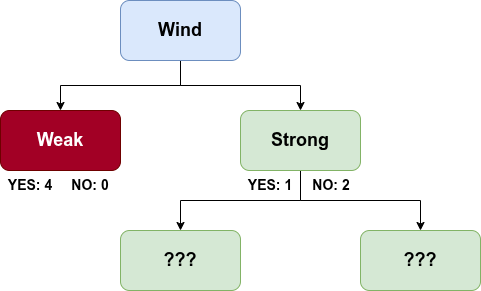

         Fig. 2. Building Decision Tree

But the remaining **Strong** node is impure: single **Yes** and two **No** samples suggest that the road to purity has not beed finished yet. By picking other two features, namely **Weather** and **Temp** we should decide which one is better for prediction. Fortunately, this step is almost the same as before: we filter samples where **Wind** feature equals **Strong**, then for each feature (**Weather**, **Temp**) we create the candidate leaves, compute **Gini** index and **weighted Gini** values and compare them. These results are shown in the table below.

| Weather | Yes | No | Total | Gini |
| ------- | --- | -- | ----- | ---- |
| Sunny   | 0   | 1  | 1     | 0.0  |
| Cloudy  | 1   | 0  | 1     | 0.0  |
| Rainy   | 0   | 1  | 1     | 0.0  |

**Weighted Gini** = (1/3)*0 + (1/3)0 + (1/3)0 = 0.0 which signifies a perfect purity for all branches.

| Temp < t | Left (Yes/No) | Gini(L) | Right (Yes/No) | Gini(R) | Weighted Gini                   |
| -------- | ------------- | ------- | -------------- | ------- | ------------------------------- |
| 21       | 0/1           | 0.0     | 1/1            | 0.5     | (1/3)*0 + (2/3)*0.5 = **0.333** |
| 25       | 1/1           | 0.5     | 0/1            | 0.0     | (2/3)*0.5 + (1/3)*0 = **0.333** |


As we can see, the **Weather** leaf has smaller **Gini** value, so we should pick it to produce the final predictive layer. But here is the problem: this feature has three values while pure **CART** support only the binary nodes. To resolve this issue, **CART** will compare three possible partitions:

1. Left: {**Sunny**} → No

Right: {**Cloudy**, **Rainy**} → Yes, No → mixed

2. Left: {**Cloudy**} → Yes

Right: {**Sunny**, **Rainy**} → No, No → pure

3. Left: {**Rainy**} → No

Right: {**Sunny**, **Cloudy**} → No, Yes → mixed.

The best partition in the second one with the lowest **Gini** index equals to 0.

Even though there are three categories (Sunny, Cloudy, Rainy), **CART** finds a binary grouping that yields pure leaves. And that's it, our binary classification tree is completed. But what about **Temp**? In our small example,temperature will not appear in the **CART** tree. This is due to the fact that the categorical feature **Weather** already produces perfect purity at the node, so **Temp** provides no better split. So **CART** did not include this feature in the final tree.

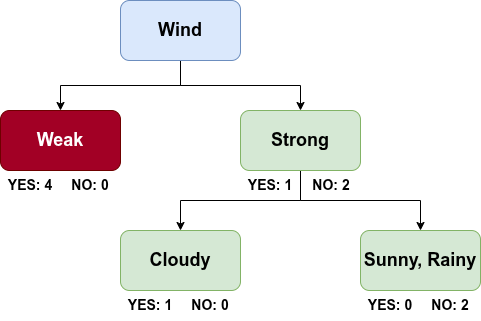

               Fig. 3. Final Decision Tree

# **4. Mechanics of Prunning**

Before we dive into more advanced concepts, let's revise the **over-fitting** problem. Overfitting happens when a decision tree becomes too complex and learns not only the true patterns in the training data, but also random noise, outliers, and fluctuations that do not generalize to new data.

Decision trees keep splitting the data into smaller and purer subsets. If not restricted, they may continue splitting until:

1. Each leaf contains very few samples (even 1);

2. The tree memorizes the dataset;

3. It starts capturing noise instead of patterns.

A highly overfitted tree usually looks deep and bushy, with many branches/leaves.

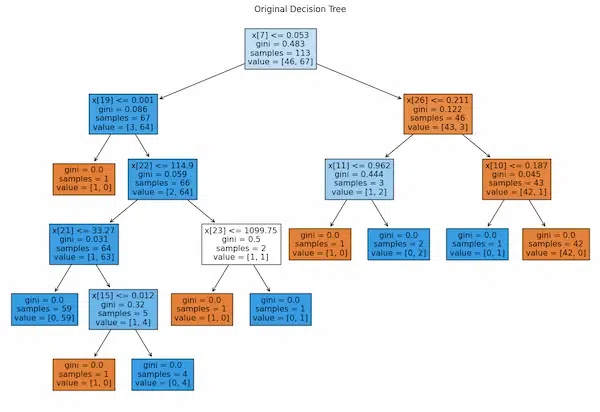

             Fig. 4. Example of over-fitted tree.

*Source: https://www.geeksforgeeks.org/machine-learning/pruning-decision-trees/*

There are variety of methods how to deal with such issue (see table below). One of the effective approaches is called **prunning**. Pruning in **CART** is the process of cutting back (removing) parts of a fully grown decision tree to prevent overfitting and improve its performance on unseen data.
**CART** (Breiman et al., 1984) uses a very specific and famous pruning method called **Cost-Complexity Pruning**.

| Method                                        | Explanation                                                |
| --------------------------------------------- | ---------------------------------------------------------- |
| Limit maximum depth (`max_depth`)             | Stops tree from growing too deep                           |
| Minimum samples per leaf (`min_samples_leaf`) | Each leaf must contain enough data                         |
| Pruning                                       | Remove unnecessary branches and simplify the tree          |
| Use ensemble methods                          | Random Forests, Gradient Boosting help control overfitting |
| Cross-validation                              | Helps ensure generalization to new data                    |


The goal of **Cost-Complexity Pruning** or **weakest link pruning** is to reduce overfitting by making the decision tree smaller, without losing too much accuracy. In this algorithm, we have two important quantities:

$$R(\textbf{T}) = \text{sum of errors (impurities) at all leaves of the tree},$$
and
$$|\textbf{T}| = \text{number of leaf nodes in the tree}.$$

A fully grown tree usually has low $R(\textbf{T})$ which signifies great training accuracy and large $∣\textbf{T}∣$ which describes high complexity of the tree. Such characteristics usually point to the risk of overfitting.

For a single node *i* treated as a leaf, we compute its error as:

$$
R(i) = Gini(i)*\text{Number Of Samples in }i.
$$

Then, for the sub-tree $\textbf{T}_i$ rooted at *i*:

$$
R(\textbf{T}_i) = \sum_{l \in \text{leaves}\textbf{T}_i}R(l) .
$$


To balance accuracy and simplicity, **CART** adds a penalty for the size of the tree:

$$R_{\alpha}(\textbf{T}) = R(\textbf{T}) + \alpha|\textbf{T}|, $$

where $\alpha \ge 0$ specifies how strongly we penalize complexity: higher $\alpha$ favors smaller trees.

To decide whether this simplification is worthwhile, **CART** evaluates how costly it is to keep the sub-tree instead of pruning it.

When considering pruning a subtree $\textbf{T}_i$ rooted at node *i* we define:

 This cost is quantified by the cost–complexity measure:


$$\alpha(i) = \frac{R(i) - R(\textbf{T}_i)}{|\textbf{T}_i| - 1},$$

where

*i* is a root node considered as a single leaf (collapsed subtree);

$\mathbf{T}_i$ is the full subtree rooted at node *i*;

$|\mathbf{T}_i|$ is the number of leaves in that subtree;

$R(\textbf{T}_i)$ is the total error (impurity) of that subtree;

$R(i)$ is the error if the subtree is replaced by a single leaf *i*.


If $\alpha(t)$ is small, pruning this subtree increases error only slightly per leaf removed — it is a good candidate for pruning. Otherwise, pruning would cause a large increase in error, so we should keep it.

Therefore, pruning it results in a simpler tree with minimal sacrifice in accuracy.

The **CART** pruning algorithm does not prune everything at once.
Instead, it repeats the following process gradually:

1. Compute $\alpha(i)$ for all internal nodes (subtree roots);

2. Prune the subtree with the smallest $\alpha(i)$ — the weakest branch. This produces a new tree with fewer leaves;

3. Update the tree and recompute $\alpha(i)$;

4. Repeat until the tree is pruned to a single root or desired complexity;

5. Select the optimal subtree using a cross-validation dataset to choose the best $\alpha$.


Cost-complexity pruning systematically balances accuracy and simplicity, producing trees that generalize better to unseen data. By iteratively removing the weakest branches, we reduce overfitting while retaining the most informative structure, resulting in a robust, interpretable decision tree model.

# **5. Code Example**

Below is the example of prunning mechanics for standard IRIS dataset.

Hewe we compute test accuracy for each alpha along the pruning path. Then, we find all trees whose accuracy is within 1% of the best test accuracy. Afther this step, we pick largest alpha among them, giving the simplest tree that still performs well.

Best alpha for simplest tree within tolerance: 0.00899
Accuracy of simplest pruned tree: 0.933


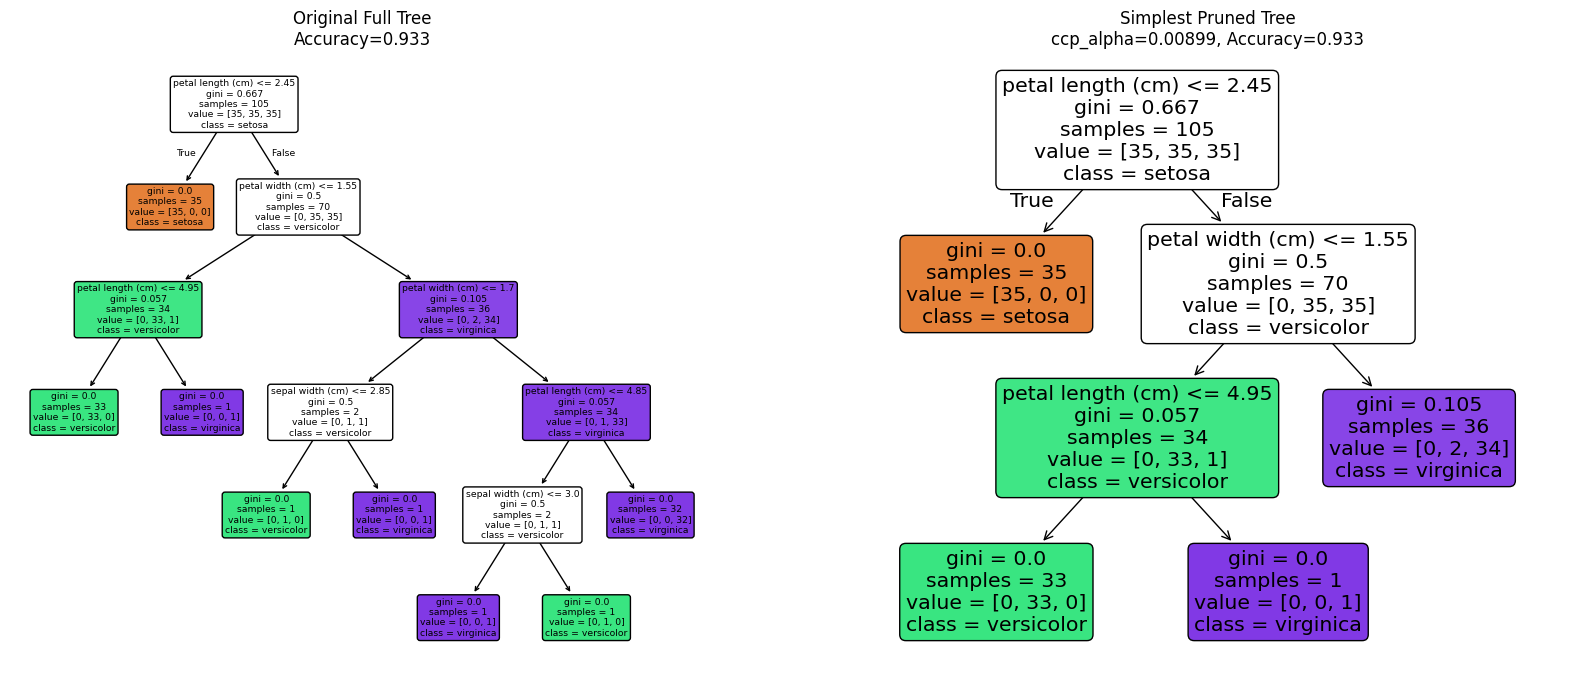

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

test_acc = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

test_acc = np.array(test_acc)
best_acc = test_acc.max()
tolerance = 0.01

# Find the simplest tree within tolerance
acceptable_alphas = ccp_alphas[test_acc >= best_acc - tolerance]
best_simple_alpha = acceptable_alphas.max()  # largest alpha = simplest tree

print(f"Best alpha for simplest tree within tolerance: {best_simple_alpha:.5f}")

# Train pruned tree
tree_simple = DecisionTreeClassifier(random_state=42, ccp_alpha=best_simple_alpha)
tree_simple.fit(X_train, y_train)

# Accuracy
acc_simple = accuracy_score(y_test, tree_simple.predict(X_test))
print(f"Accuracy of simplest pruned tree: {acc_simple:.3f}")

# Plot comparison: Full vs Simplest Pruned
plt.figure(figsize=(20,8))

# Original full tree
plt.subplot(1,2,1)
plot_tree(
    tree_full,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True
)
plt.title(f"Original Full Tree\nAccuracy={acc_full:.3f}")

# Simplest pruned tree
plt.subplot(1,2,2)
plot_tree(
    tree_simple,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True
)
plt.title(f"Simplest Pruned Tree\nccp_alpha={best_simple_alpha:.5f}, Accuracy={acc_simple:.3f}")

plt.show()

# **6. Feature Importance**

**Decision trees** work by splitting the data using features to reduce impurity (Gini, entropy, etc.). So, a feature is considered important if **it reduces impurity a lot and/or it is used often near the top of the tree.** Feature importance measures how much each feature contributed to building the tree.


To formalize the definition, let's consider some feature $f_1$ which appeares at $k$ splits. So, its importance is calculated as follows:

$$
\textbf{I}(f_1) = \sum_{i=1}^{k}[Gini(parent_i)-(\frac{N_{\textbf{L},i}}{N_i}*Gini(\textbf{L}_j)+\frac{N_{\textbf{R},i}}{N_i}*Gini(\textbf{R}_i))].
$$

Here, $N_{\textbf{L},i}$ is the number of samples in left nodes $\textbf{L}$ at i-th splits, $N_{\textbf{R},i}$ is the number of samples in right nodes $\textbf{L}$ at i-th splits, $N_i$ is the number of samples in the parent node at i-th split. The importance score for each feature should be normalized in order to make feature importances comparable across all of them such that their sum equals to 1.


$$
\textbf{I}_{norm}(f_1) = \frac{\textbf{I}(f_1)}{\sum_{j=1}^{M}\textbf{I}(f_j)},
$$

where $M$ is the total number of features.